### Импорты, настройки

In [62]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from functools import reduce

from tqdm import tqdm

from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

from gensim import corpora
from gensim.models import LdaModel
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
nltk.download('stopwords')
import string
import re

import numpy as np


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/smertlove/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)
%matplotlib inline

RANDOM_STATE = 42

### Загрузка датасета, осмотр владений

In [21]:
sharing_url = "https://drive.google.com/file/d/1zLs02TTxbt1Htk1RdIJM5AaBacs6Y39K/view?usp=sharing"
download_url = "https://drive.google.com/uc?id=" + sharing_url.split("/")[-2]

df = pd.read_csv(download_url)

In [22]:
df.head()

,Title,URL,Question,Categories
0,your browser version is not supported using symfony browserkit,https://stackoverflow.com/questions/76981459/your-browser-version-is-not-supported-using-symfony-browserkit,"I'm trying to automate some features and I need to scarp a web page.So, I'm using browserkit to make external request to website.Everything seems good but there's no useful result in my response because target page is using modern JavaScript.Let's take a look :PHP filerequire ""./vendor/autoload.php"";use Symfony\Component\HttpClient\HttpClient;$client = HttpClient::create([ 'max_redirects' => 7,]);$response = $client->request( 'GET', 'https://secure.e-konsulat.gov.pl');$statusCode = $response->getStatusCode();$contentType = $response->getHeaders()['content-type'][0];$content = $response->getContent();dd($content); //dd() is installed globally on my php installationand this is $content result:^ """"""<!DOCTYPE html><html lang=""en""><head> <meta charset=""utf-8""> <title>System Zdalnej Rejestracji</title> <base href=""/""> <meta name=""viewport"" content=""width=device-width, initial-scale=1""> <link rel=""icon"" type=""image/x-icon"" href=""favicon.ico""> <link rel=""preconnect"" href=""https://fonts.gstatic.com""> <style type=""text/css"">@font-face{font-family:'Material Icons';font-style:normal;font-weight:400;src:url(https://fonts.gstatic.com/s/materialicons/v139/flUhRq ▶<style>*,:after,:before{box-sizing:border-box;}@media (prefers-reduced-motion:no-preference){:root{scroll-behavior:smooth;}}body{margin:0;font-family:var(--bs-f ▶<body> <!--[if lt IE 11]> <div style=""padding: 1em; border-bottom: 1px solid #0052a5;"">Serwis Ministerstwa Spraw Zagranicznych Rzeczypospolitej Polskiej</div> <div style=""font-size: 1.5em; margin: 4em auto; max-width: 1024px; text-align: center;""> <br /> <p>Dear User,</p><br /> <p>Your browser's version is not supported by the application.</p><br /><br /> Please, actualize Your browser or use another one </div> <![endif]--> <app-root></app-root><script src=""runtime.31b3be7ffe3f39288917.js"" defer></script><script src=""polyfills.da272157cf92c2e29a93.js"" defer></script><script src=""main.375c8bb1538d8323b9 ▶</body></html>""""""and as you can see in this lines: <p>Dear User,</p><br /><p>Your browser's version is not supported by the application.</p><br /><br />Please, actualize Your browser or use another oneDo you know how to solve this issue?And as a mention it's my first experience on web scraping so detailed answers are appreciated.Thanks in advance","['php', 'symfony', 'web-scraping']"
1,how to get button text value in java,https://stackoverflow.com/questions/76981456/how-to-get-button-text-value-in-java,"I want to get button text value to do the on click command, but i can't find the right code to do it. I think I need a code to replace the //button text value// on the code showed below.package test;import javax.swing.*;import java.awt.*;import java.awt.event.*;public class Main implements ActionListener{public static void main(String[] args) { JFrame frame = new JFrame(); frame.setSize(420,420); frame.setLayout(new GridLayout(1,1)); frame.setDefaultCloseOperation(JFrame.EXIT_ON_CLOSE); JButton button = new JButton(); button.setText(""1""); } @Override public void actionPerformed(ActionEvent e) { if(e.getSource()==button { if(//button text value// == 1) { button.setText(""3""); } if(//button text value// == 1) { button.setText(""2""); } }","['java', 'button']"
2,How to make sure communication is stable when using a ZeroMQ REQ-REP in NodeJs-Golang,https://stackoverflow.com/questions/76981455/how-to-make-sure-communication-is-stable-when-using-a-zeromq-req-rep-in-nodejs-g,"This is my Node codeasync function runClient() { console.log('Connecting to hello world server…'); // Socket to talk to server const sock = new zmq.Request(); sock.connect('tcp://localhost:5555'); let i = 0; while (true) { const msgToSend = 'Hello'; console.log(`Count: ${i} Sending: ${msgToSend}`); await sock.send(msgTo

In [23]:
df.shape

(22123, 4)

In [24]:
df.describe()

,Title,URL,Question,Categories
count,22123,22123,22123,22123
unique,22122,22123,22083,18106
top,Seeking Suggestions for Comparing Handwritten Input on HTML Canvas with Font Letter for Accuracy [closed],https://stackoverflow.com/questions/76981459/your-browser-version-is-not-supported-using-symfony-browserkit,"How do I return the response/result from a function foo that makes an asynchronous request?I am trying to return the value from the callback, as well as assigning the result to a local variable inside the function and returning that one, but none of those ways actually return the response — they all return undefined or whatever the initial value of the variable result is.Example of an asynchronous function that accepts a callback (using jQuery's ajax function):function foo() { var result; $.ajax({ url: '...', success: function(response) { result = response; // return response; // <- I tried that one as well } }); return result; // It always returns `undefined`}Example using Node.js:function foo() { var result; fs.readFile(""path/to/file"", function(err, data) { result = data; // return data; // <- I tried that one as well }); return result; // It always returns `undefined`}Example using the then block of a promise:function foo() { var result; fetch(url).then(function(response) { result = response; // return response; // <- I tried that one as well }); return result; // It always returns `undefined`}",['python']
freq,2,1,5,176


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22123 entries, 0 to 22122
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       22123 non-null  object
 1   URL         22123 non-null  object
 2   Question    22123 non-null  object
 3   Categories  22123 non-null  object
dtypes: object(4)
memory usage: 691.5+ KB


In [26]:
df.nunique()

Title         22122
URL           22123
Question      22083
Categories    18106
dtype: int64

In [27]:
df.iloc[666]["Question"]

"I am trying to limit the amount of GPU reserved by PyTorch. Yolo8 offers workspace parameter that limits the PyTorch reserved memory. How can I do it in general (not limited to Yolo8)? I've tried to add a system variable CUDNN_CONV_WSCAP_DBG 2048 (additional -> system variables), but I still getCUDA out of memory. Tried to allocate 2.52 GiB (GPU 0; 6.00 GiB totalcapacity; 4.59 GiB already allocated; 0 bytes free; 4.61 GiB reservedin total by PyTorch)"

In [28]:
df.iloc[666]["Categories"]

"['python-3.x', 'memory', 'pytorch']"

In [29]:
def preproc_categories(categories: str) -> list:
    return [
        c.strip("'")
        for c
        in categories[1:-1].split(", ")
    ]

In [30]:
(c := preproc_categories(df.iloc[666]["Categories"]), type(c), type(c[0]))

(['python-3.x', 'memory', 'pytorch'], list, str)

In [31]:
categories = tuple(
    reduce(
        lambda s1, s2: s1 | s2,
        (
            set(preproc_categories(elem))
            for elem
            in df["Categories"]
        )
    )
)
len(categories)

10634

In [32]:
categories[:10]

('final-form',
 'protocol-buffers',
 'safari-web-extension',
 'dart-pub',
 'image',
 'wordtopdf',
 'wysiwyg',
 'recharts',
 'audiokit',
 'thorpy')

Кажется, наименования категорий произвольные и никак не помогут эмпирически определить количество кластеров

### Сначала сразу добавим колонку с предобработанным текстом. Потом обучим модельки.

### Предобработка текста

- Удаление пунктуации
- Приведение к нижнему регистру
- Токенизация
- Удаление стоп-слов
- Лемматизация

In [47]:
lemmatizer = WordNetLemmatizer()

In [48]:
def tidy_tokenize_and_lemmatize(
    text:str,
    tokenize=nltk.word_tokenize,
    lemmatize=lemmatizer.lemmatize,
    stopwords=set(stopwords.words('english')),
) -> list[str]:

    no_punct_text = re.sub(
        fr"[{string.punctuation}]+",
        " ",
        text.lower()
        # Для этого паттерна флажки вроде не нужны
    )

    tokens = tokenize(no_punct_text)

    return [lemmatize(token) for token in tokens if token not in stopwords]

In [49]:
tidy_tokenize_and_lemmatize(
    "He just likes looking after cars." \
    "Get Dags. Do you like Dags? Dags? What?" \
    "Yeah, Dags. Dags. You like Dags? Oh, dogs. Sure. I like dags."
)

['like',
 'looking',
 'car',
 'get',
 'dag',
 'like',
 'dag',
 'dag',
 'yeah',
 'dag',
 'dag',
 'like',
 'dag',
 'oh',
 'dog',
 'sure',
 'like',
 'dag']

In [50]:
df["Question_preproc"] = df["Question"].apply(
    lambda text: " ".join(tidy_tokenize_and_lemmatize(text))
)

In [52]:
df.iloc[666]["Question_preproc"]

'trying limit amount gpu reserved pytorch yolo8 offer workspace parameter limit pytorch reserved memory general limited yolo8 tried add system variable cudnn conv wscap dbg 2048 additional system variable still getcuda memory tried allocate 2 52 gib gpu 0 6 00 gib totalcapacity 4 59 gib already allocated 0 byte free 4 61 gib reservedin total pytorch'

In [51]:
df.nunique()

Title               22122
URL                 22123
Question            22083
Categories          18106
Question_preproc    22082
dtype: int64

Понятно, что на стаковерфлоу часто задаются одинаковые вопросы. Но тут один совпал с точностью до лемм))

### Векторизация

In [ ]:
glove_file = './data/glove.6B.100d.txt'  # пример файла
word2vec_output_file = './data/glove.6B.100d.word2vec'
glove2word2vec(glove_file, word2vec_output_file)
glove_model = KeyedVectors.load_word2vec_format(word2vec_output_file, binary=False)

/tmp/ipykernel_13972/1565634028.py:3: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_file, word2vec_output_file)


In [ ]:
glove_ndim = glove_model.get_vector("hello").shape
glove_ndim

100

In [79]:
def doc2glove(doc: str, model=glove_model, tokenize=nltk.word_tokenize, ndim=glove_ndim):

    vectors = [
        model.get_vector(token)
        for token
        in tokenize(doc)
        if token in model.key_to_index
    ]

    if vectors:
        return np.mean(vectors, axis=0)

    else:
        return np.zeros(ndim, dtype=np.float32)

In [80]:
(vec := doc2glove(
    "He just likes looking after cars." \
    "Get Dags. Do you like Dags? Dags? What?" \
    "Yeah, Dags. Dags. You like Dags? Oh, dogs. Sure. I like dags."
), vec.shape)

(array([-0.08911381,  0.39290887,  0.5942723 , -0.6717133 , -0.28521585,
         0.22869025,  0.02713791,  0.09154001,  0.19138518, -0.25101554,
         0.23336983, -0.22791176,  0.2037703 ,  0.12573841,  0.3180231 ,
        -0.28414342,  0.06970172,  0.2423384 , -0.4799577 ,  0.47129995,
         0.17900166,  0.23475927,  0.09581273, -0.03740849,  0.42782286,
         0.35768902, -0.20655781, -0.6633259 ,  0.05046322, -0.27931935,
        -0.02596642,  0.46478584,  0.02282623, -0.0903082 ,  0.06381155,
         0.3540638 , -0.01158935,  0.21150489,  0.20381913, -0.45705298,
        -0.16385761, -0.26534846, -0.11073317, -0.4459816 , -0.42916185,
        -0.17288972,  0.1175564 , -0.4256349 , -0.13640887, -0.73082006,
         0.06337049, -0.04371006,  0.0542897 ,  1.1258153 , -0.268021  ,
        -2.3526888 , -0.02986763,  0.05942595,  1.251538  ,  0.57282984,
        -0.32213908,  0.9289303 , -0.10883453,  0.03467202,  0.80103725,
        -0.01638763,  0.70500815,  0.29742363,  0.2

In [81]:
(vec := doc2glove(
    "asdasd kjlqdsbD Masljdkchmaous dcasmbc lhbm lajsbc domasidcfbaiuh"
), vec.shape)

(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=float32),
 (100,))

## TF-IDF

```TFIDF(t,d,D) = TF(t,d) * IDF(t,D)```

где
- `TF(t,d)` это отношение частоты термина `t` к общему количеству терминов в документе `d`
- `IDF(t,D)` это отнощение общего числа документов к числу документов, в которых есть термин `t`. Часто от нее берут логарифм, при чем без разницы по какому основанию, чтобы сгладить распределение

Смысл формулы в том, чтобы определить токены, которые хорошо объясняют дисперсию разных документов. Говоря проще, смысл в том, чтобы определить, насколько токен `t` является важным в конкретном документе `d` относительно всего корпуса документов `D`.

In [82]:
%%time
count_vectors_raw = CountVectorizer().fit_transform(df["Question"].values)
tfidf_vectors_raw = TfidfVectorizer().fit_transform(df["Question"].values)
glove_vectors_raw = np.array([doc2glove(q) for q in df["Question"].values])

CPU times: user 26.7 s, sys: 52.2 ms, total: 26.8 s
Wall time: 26.8 s


In [83]:
%%time
count_vectors_preproc = CountVectorizer().fit_transform(df["Question_preproc"].values)
tfidf_vectors_preproc = TfidfVectorizer().fit_transform(df["Question_preproc"].values)
glove_vectors_preproc = np.array([doc2glove(q) for q in df["Question_preproc"].values])

CPU times: user 14.2 s, sys: 14.4 ms, total: 14.2 s
Wall time: 14.2 s


In [84]:
count_vectors_raw.shape, tfidf_vectors_raw.shape, glove_vectors_raw.shape, count_vectors_preproc.shape, tfidf_vectors_preproc.shape, glove_vectors_preproc.shape

((22123, 249841),
 (22123, 249841),
 (22123, 100),
 (22123, 206097),
 (22123, 206097),
 (22123, 100))

### Эксперименты

In [51]:
def get_kmeans(n_clusters: int) -> KMeans:
    return KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=15,
        max_iter=500,
        random_state=RANDOM_STATE
    )

In [93]:
# def experiment(matrix: np.array):

#     inertia = {}
#     silhouette = {}
#     model = {}

#     for i in tqdm(range(2, 40, 2)):

#         kmeans = get_kmeans(i)
#         kmeans.fit(matrix)

#         inertia[i] = kmeans.inertia_
#         silhouette[i] = silhouette_score(matrix, kmeans.labels_, metric='euclidean')
#         model[i] = kmeans

#     return inertia, silhouette

In [94]:
# experiment(count_vectors_raw)
# # 100%|██████████| 19/19 [52:15<00:00, 165.02s/it]

Очень долго учится. А еще я забыл записать результаты в переменную и вернуть словарь с моделями. Всё это подталкивает переобучить штуки применив, например, PCA. Строго говоря, у нас тут получится не BoW и TfIdf, а LSA матрицы. Но что уж поделать.

In [142]:
# Исправим баг в функции
def experiment(matrix: np.array):

    inertias = {}
    silhouettes = {}
    models = {}

    for i in tqdm(range(2, 20)):

        kmeans = get_kmeans(i)
        kmeans.fit(matrix)

        inertias[i] = kmeans.inertia_
        silhouettes[i] = silhouette_score(matrix, kmeans.labels_, metric='euclidean')
        models[i] = kmeans

    return inertias, silhouettes, models

In [92]:
count_vectors_raw.shape

(22123, 249841)

In [98]:
# В среднем по закону Ципфа 100 самых частотных слов объясняют 60% текста.
# Можно попробовать применить это к нашим матрицам, только вместо слов будут главные компоненты.
new_dim = 100

In [ ]:
%%time
# Перезапишем старые переменные чтобы освободить память
count_vectors_raw = PCA(new_dim).fit_transform(count_vectors_raw)

CPU times: user 1min 14s, sys: 1.74 s, total: 1min 16s
Wall time: 5.12 s


In [100]:
tfidf_vectors_raw = PCA(new_dim).fit_transform(tfidf_vectors_raw)
count_vectors_preproc = PCA(new_dim).fit_transform(count_vectors_preproc)
tfidf_vectors_preproc = PCA(new_dim).fit_transform(tfidf_vectors_preproc)

In [102]:
count_vectors_raw.shape

(22123, 100)

In [143]:
experiments = []

for i, matrix in enumerate(
    [
        count_vectors_raw,
        tfidf_vectors_raw,
        glove_vectors_raw,
        count_vectors_preproc,
        tfidf_vectors_preproc,
        glove_vectors_preproc
    ],
    start=1
):
    experiments.append(experiment(matrix))
    print(f"{i}/6 done.")

100%|██████████| 18/18 [11:55<00:00, 39.77s/it]


1/6 done.


100%|██████████| 18/18 [12:17<00:00, 40.99s/it]


2/6 done.


100%|██████████| 18/18 [06:05<00:00, 20.29s/it]


...

4/6 done.


100%|██████████| 18/18 [12:11<00:00, 40.64s/it]


5/6 done.


100%|██████████| 18/18 [06:24<00:00, 21.38s/it]

6/6 done.


In [144]:
def plot_stuff(progon4ik, id_=1):

    inertia, silhouette, _ = progon4ik

    sns.set(font_scale=1, rc={'figure.figsize':(10,4)})
    plt.subplot(1, 2, 1)

    plt.plot(range(len(inertia)), list(inertia.values()), marker='x',color='blue')
    plt.xticks(range(len(inertia)), list(inertia.keys()))

    plt.xlabel('Число кластеров')
    plt.title(f'K-means Inertia {id_}',fontweight='bold')
    plt.grid(True)

    plt.subplot(1, 2, 2)

    plt.bar(range(len(silhouette)), list(silhouette.values()), align='center',color= 'blue')
    plt.xticks(range(len(silhouette)), list(silhouette.keys()))
    plt.grid(True)
    plt.title(f'Silhouette Score {id_}',fontweight='bold')
    plt.xlabel('Число кластеров')

    plt.show()

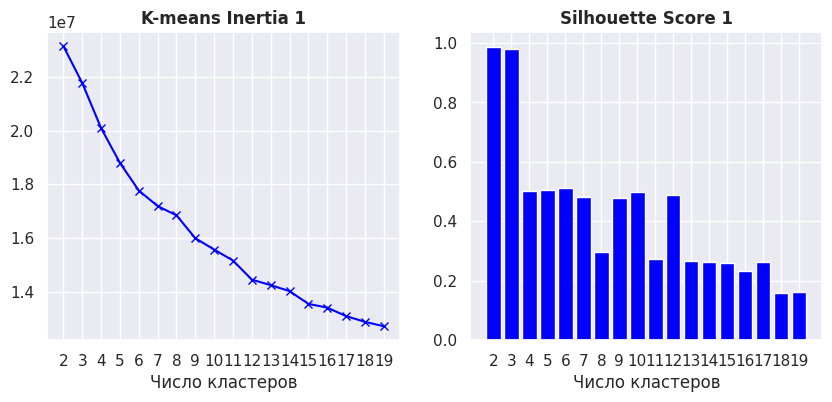

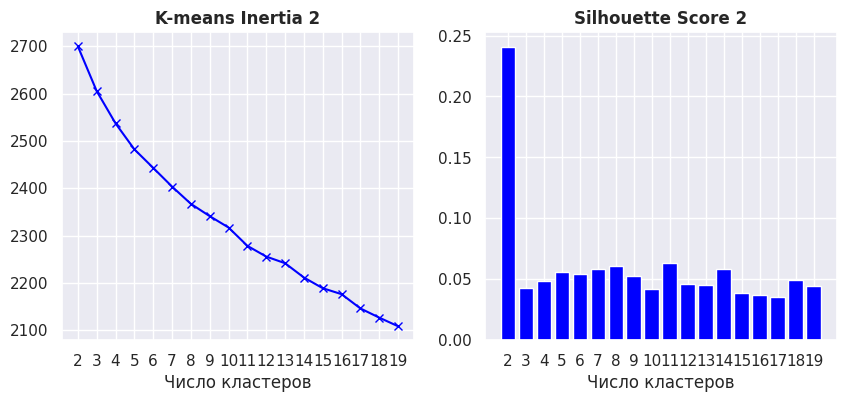

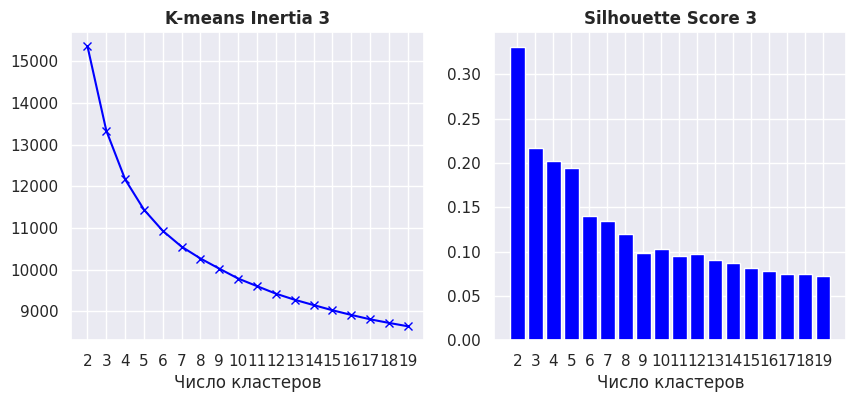

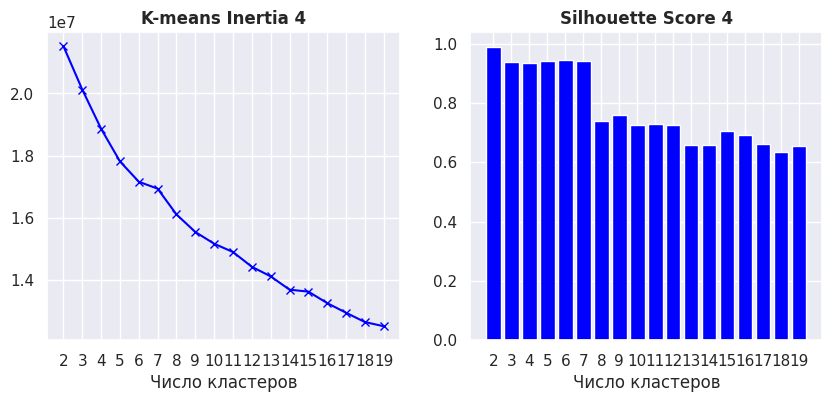

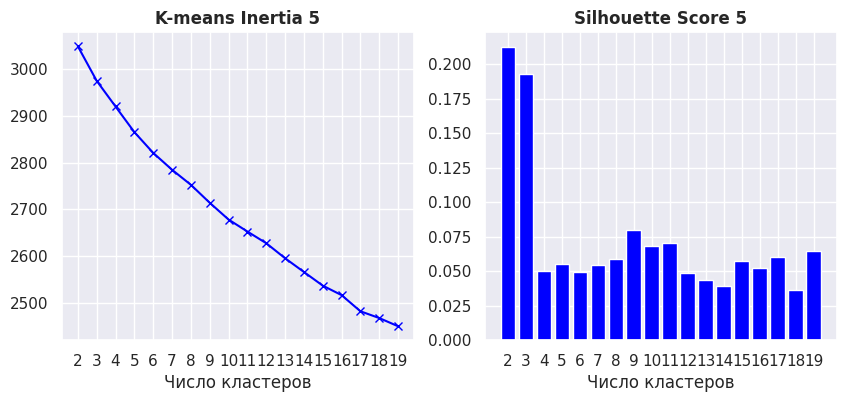

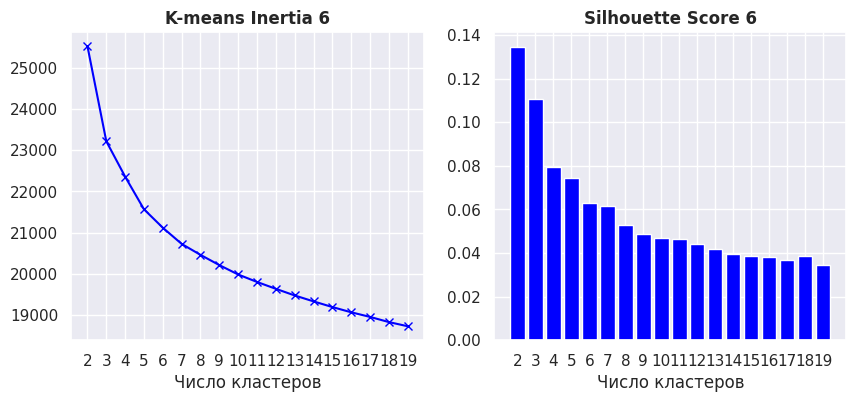

In [145]:
for i, progon4ik in enumerate(experiments, start=1):
    plot_stuff(progon4ik, i)

Выбор кол-ва кластеров будем производить методом локтя. Не будем рассматривать случаи для 2 кластеров тк это артефакт.

Эксперимент 1: Мешок слов без препроцессинга. Пик силуэта при k=6, инерция замедляет скорость убываения на этой же отметке.

Эксперимент 2: TfIdf без препроцессинга: Пик силуэта при k=8, инерция нигде не замедляет падение. Кажется, что при условии сохранения адекватного кооличества кластеров это лучший вариант.

Эксперимент 3 glove без препроцессинга: Силуэт стабильно снижается по мере увеличения количества кластеров. При k=5  он в последний раз находится около пика, далее уже совсем драматично падает. При этом же k=5 виден локоть графика инерции. Лучший вариант тут k=5.

Эксперимент 4 Мешок слов с препроцессингом:при к=6 пик силуэта, там же находится "локоть" инерции (хотя далее еще больше падает)

Эксперимент 5 TfIdf  с препроцессингом: при к=9 пик силуэта, 

Эксперимент 6 glove  с препроцессингом: Силуэт стабильно снижается по мере увеличения количества кластеров. При k=4, k=5 наблюдается "локоть" графика инерции, там же находится компромиссной величины силуэт. Можно попробовать взять k=5.

### Далее будут попытки интерпретировать семантику кластеров по ближайшим к центроидам текстам.

Стоит отметить, что в идеале стоит смотреть больше данных для интерпретации. Делать выводы только по 1 тексту в каждом случае это очень навино и опрометчиво, даже если он находится в центре кластера. Нужно смотреть на пересекающиеся признаки у нескольких (в идеале у всех в кластере) текстов.

In [177]:
def get_closest_ids(model: KMeans, matrix: np.array):
    return [
        cosine_similarity(
            centroid.reshape(1, -1),
            matrix
        ).argmax()
        for centroid
        in model.cluster_centers_
    ]

def make_text_readable(text:str, n=64):
    return re.sub("(.{" + str(n) + "})", "\\1\n", text, 0, re.DOTALL)

In [ ]:
def print_closest_texts(experiment_model, matrix, df):
    for i, row in enumerate(
        df.iloc[
            get_closest_ids(
                experiment_model,
                matrix
            )
        ]["Question"],
        start=1
    ):
        print(i)
        print(make_text_readable(row, 128)[:384], end="\n\n")

In [202]:
ms = [
    count_vectors_raw,
    tfidf_vectors_raw,
    glove_vectors_raw,
    count_vectors_preproc,
    tfidf_vectors_preproc,
    glove_vectors_preproc
]

In [ ]:
#                                                                          n_clusters
for i, experiment, matrix, n_clusters in zip(range(1, 7), experiments, ms, [6, 8, 5, 6, 9, 5]):
    print(f"----- Experiment {i} -----")
    print_closest_texts(
        experiment[2][n_clusters],
        matrix,
        df
    )

----- Experiment 1 -----
1
I have this Liquid template:Hello, {% foo %} world!I would like to remove the foo tag from here and all other tags too, to obtai
n a clean document, without any Liquid markup:Hello,  world!Is it possible, using existing Liquid tools?

2
I want to find the mean (for numerical variables) and mode (for character variables) for each of the variables under column "tra
it_name" for each unique "taxon_name". I would then like to tabulate these values.This is what my dataframe looks like currently
 (I also have a wide version):This is my desired output:I've written code that manually calculates the mean and mode for each 

3
When I try to create a sparkSession using spark-shell, a stack overflow error occurs. I traced the stack overflow to a problem w
ith scala-reflect-2.12.10.jar path handling and triggered by spark when creating the sessionState, but I can't get any more deta
ils.What specific actions trigger this problem when spark creates a sparSession and how sh

### Интерпретация результатов

Судя по метрикам, для BoW подхода препроцессинг помог существенно улучшить качество кластеризации: для любого количества кластеров метрика силуэта сильно увеличилась, и инерция сходится сильно лучше. То же самое касается подхода с TfIdf, хотя там улучшение видно не так явно.

А вот для glove подхода метрики показывают ухудшение, что на первый взгляд контринтуитивно (тк без препроца в расчет не попадали все слова в апперкейсе, например), но если задуматься, то может оказаться, что много важной информации о документах съедается лемматизацией: glove вектора хранят информацию о формах, клитиках, стоп-слова и пунктуация могут оказаться важными. Вообще недавно была статья, правда, про берт, где говорилось, что он очень много контекстуальной информации хранит в артиклях и пунктуации. Возможно, здесь частично наблюдается тот же эффект. Хотя glove вектора по сути не несут информацию о контексте, сами по себе векторы пунктуации, форм слов и стоп-слов могут нести какую-то особую информацию, отличающую их от нормализованных аналогов и теряющуюся при удалении соответствующих им токенов.

### Любой другой алгоритм кластеризации

Возьмем DBSCAN. Сравним с KMeans по силуэту.

In [225]:
(
    # BoW
    experiments[3][1][6],

    # TfIdf
    experiments[4][1][9],

    # glove
    experiments[5][1][5],
)

(0.9436862817698164, 0.07952321417942768, 0.07421673)

In [ ]:
# Функция писалась для подбора параметров,
# но почему-то вообще любая комбинация параметров кроме дефолтной валилась с ошибкой на этапе замера silhouette,
# поэтому в итоге есть только замер DBSCAN в стоковом виде
def dbscan_experiment(get_dbscan):
    dbscan_bow = get_dbscan()
    dbscan_tfidf = get_dbscan()
    dbscan_glove = get_dbscan()

    dbscan_bow.fit(count_vectors_preproc)
    dbscan_tfidf.fit(tfidf_vectors_preproc)
    dbscan_glove.fit(glove_vectors_preproc)

    return (
        silhouette_score(
            # Делаем такой странный срез потому что там аутлаеры
            count_vectors_preproc[dbscan_bow.labels_ != -1],
            dbscan_bow.labels_[dbscan_bow.labels_ != -1]
        ),
        silhouette_score(
            count_vectors_preproc[dbscan_tfidf.labels_ != -1],
            dbscan_tfidf.labels_[dbscan_tfidf.labels_ != -1]
        ),
        silhouette_score(
            count_vectors_preproc[dbscan_glove.labels_ != -1],
            dbscan_glove.labels_[dbscan_glove.labels_ != -1]
        )
    )

In [249]:
dbscan_experiment(lambda: DBSCAN())

(0.40421686501104964, 0.044954126567750455, 0.16030734681022565)

Если судить по метрике силуэта, DBSCAN лучше сработал с glove, но хуже со статистическими векторизаторами. Впрочем, можно было бы попробовать побустить качество путем подбора параметров для него.

### Векторизация через sentence-transformers

In [ ]:
# торча нет чтобы написать через .torch.cuda.is_available()
DEVICE = "cuda"

In [ ]:
minilm_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2').to(DEVICE)

In [35]:
def get_vectors(to_encode: str|list[str], vectorizer=minilm_model):

    result = vectorizer.encode(to_encode)

    if isinstance(to_encode, str):
        result = result.reshape(1, -1)

    return result

In [36]:
get_vectors(
    "He just likes looking after cars." \
    "Get Dags. Do you like Dags? Dags? What?" \
    "Yeah, Dags. Dags. You like Dags? Oh, dogs. Sure. I like dags."
).shape

(1, 384)

In [37]:
get_vectors(
    [
        "He just likes looking after cars.",
        "Get Dags. Do you like Dags? Dags? What?",
        "Yeah, Dags. Dags. You like Dags? Oh, dogs. Sure. I like dags.",
    ]
).shape

(3, 384)

In [39]:
# Энкодер трансформерный поэтому предобработка не нужна
minilm_vectors_raw = get_vectors(df["Question"].values)

In [40]:
minilm_vectors_raw.shape

(22123, 384)

In [ ]:
agglomerative_minilm = AgglomerativeClustering(n_clusters=None, distance_threshold=0.3)

In [45]:
agglomerative_minilm.fit(minilm_vectors_raw)

AgglomerativeClustering(distance_threshold=0.3, n_clusters=None)

In [47]:
silhouette_score(
    minilm_vectors_raw,
    agglomerative_minilm.labels_
)

0.0042813844

In [48]:
agglomerative_minilm_2 = AgglomerativeClustering(n_clusters=5)
agglomerative_minilm_2.fit(minilm_vectors_raw)
silhouette_score(
    minilm_vectors_raw,
    agglomerative_minilm_2.labels_
)

0.0045442376

In [52]:
agglomerative_kmeans = get_kmeans(5)
agglomerative_kmeans.fit(minilm_vectors_raw)
silhouette_score(
    minilm_vectors_raw,
    agglomerative_kmeans.labels_
)

0.026304077

### BERTopic

In [55]:
topic_model = BERTopic()

In [56]:
topics, probs = topic_model.fit_transform(df["Question"])

/home/smertlove/sandbox/hse/ML_hw/.venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The curr

In [61]:
topic_model.get_topic_info().drop("Representative_Docs", axis=1)

,Topic,Count,Name,Representation
0,-1,10493,-1_the_to_and_is,"[the, to, and, is, this, in, it, of, for, that]"
1,0,452,0_const_component_div_useeffect,"[const, component, div, useeffect, usestate, state, react, button, from, return]"
2,1,350,1_na_000_dataframe_nan,"[na, 000, dataframe, nan, 2l, 78, 76, 77, 0l, 79]"
3,2,342,2_token_authentication_user_access,"[token, authentication, user, access, spring, login, azure, security, jwt, oauth]"
4,3,342,3_line_module_file_python,"[line, module, file, python, import, install, pip, package, installed, conda]"
...,...,...,...,...
241,240,10,240_reservationdto_datasource_public_responseentityuser,"[reservationdto, datasource, public, responseentityuser, apiresponseresponsecode, reservation, listproduct, private, product, mynet]"
242,241,10,241_sed_replace_ssomestringp_awk,"[sed, replace, ssomestringp, awk, bash, fileregex, 2s, qn, 1s, regex]"
243,242,10,242_clientname_surfaceview_intent_rewarditem,"[clientname, surfaceview, intent, rewarditem, void, override, uid, checkconnections, alarmtask, permission]"
244,243,10,243_spring_camel_inputstream_channelsftp,"[spring, camel, inputstream, channelsftp, setbody, inputstreamsource, convertersaddnew, bytes, override, multipartfile]"


id=4: `[line, module, file, python, import, install, pip, package, installed, conda]` очень жизненно.

### LDA Topic Modeling

In [63]:
stop_words = set(STOPWORDS)

In [64]:
texts = [
    [
        word
        for word
        in simple_preprocess(doc)
        if word not in stop_words
    ]
    for doc
    in df["Question"]
]

In [65]:
dictionary = corpora.Dictionary(texts)

In [66]:
corpus = [dictionary.doc2bow(text) for text in texts]

In [67]:
num_topics = 5

In [68]:
lda_model = LdaModel(
    corpus,
    num_topics=num_topics,
    id2word=dictionary,
    passes=15
)

In [69]:
for idx, topic in lda_model.print_topics(-1):
    print(f"Тема {idx + 1}: {topic}")

Тема 1: 0.016*"self" + 0.009*"int" + 0.009*"data" + 0.007*"return" + 0.007*"val" + 0.006*"new" + 0.006*"model" + 0.006*"value" + 0.006*"true" + 0.005*"code"
Тема 2: 0.012*"data" + 0.011*"error" + 0.011*"string" + 0.011*"return" + 0.010*"id" + 0.009*"user" + 0.009*"public" + 0.008*"new" + 0.006*"file" + 0.006*"request"
Тема 3: 0.021*"div" + 0.016*"const" + 0.016*"class" + 0.014*"text" + 0.010*"button" + 0.009*"px" + 0.009*"id" + 0.008*"import" + 0.007*"width" + 0.007*"td"
Тема 4: 0.014*"question" + 0.008*"closed" + 0.008*"code" + 0.008*"file" + 0.007*"problem" + 0.007*"want" + 0.007*"error" + 0.006*"improve" + 0.005*"tried" + 0.005*"answers"
Тема 5: 0.024*"java" + 0.018*"org" + 0.013*"android" + 0.010*"lib" + 0.010*"com" + 0.009*"app" + 0.009*"js" + 0.009*"import" + 0.009*"file" + 0.008*"error"
